I want to illustrate the fact that the standard Brownian motion has no drift and increasing variance, so the longer the time intervals, the wider possible spreads

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

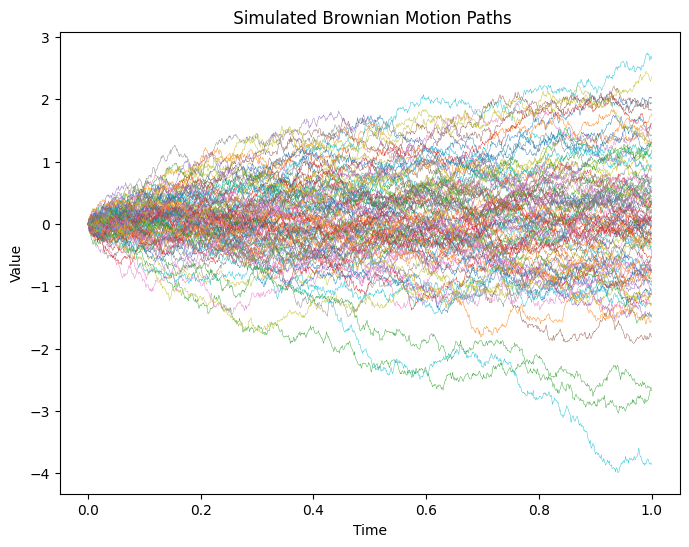

In [10]:
def sim_BM(T, Ndt, Nsims=10):
        
    # time increment
    dt = T / Ndt
    
    # set the different times as a vector
    time = np.linspace(0, T, Ndt+1)
    
    # initialize the matrix for the RW
    W = np.zeros((Ndt+1,Nsims))
    
    # initial value of the process
    W[0,:] = 0
    
    # recursively simulate the process ( W[idx,:] is (1 , Nsims) )
    for i in range(Ndt):
        Z = np.random.normal(0,1,Nsims)
        W[i+1,:] = W[i,:] + np.sqrt(dt) * Z
    return time, W

#Parameters
T=1
Ndt = 1000
Npaths=100

#Seed
np.random.seed(123)

#Simulate
t, W = sim_BM(T,Ndt,Npaths)
   
# plot the sample paths
plt.figure(figsize=(8, 6))
plt.plot(t, W[:,1:100], linewidth=0.3)
plt.title(r" Simulated Brownian Motion Paths")
plt.xlabel('Time')
plt.ylabel('Value')



plt.show()

Illustration of Geometric Brownian Motion for the theory section

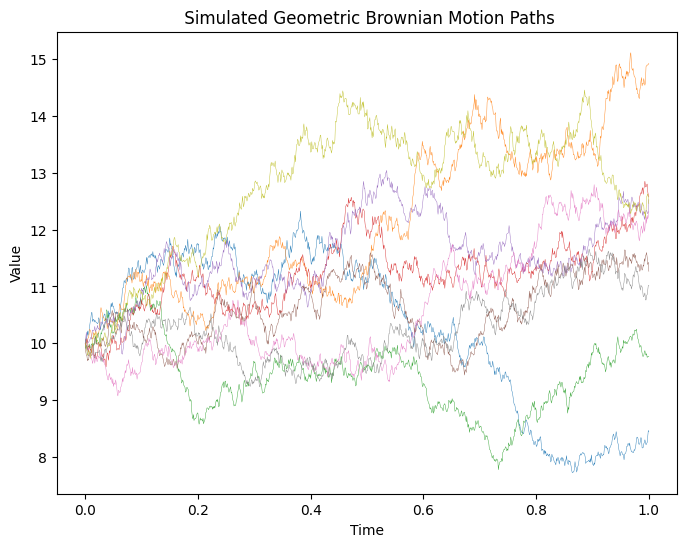

In [ ]:
np.random.seed(123)

#Parameters
X0 = 10
mu = 0.2
sigma = 0.2
T = 1
Ndt = 1000
Nsims = 500

def simulate_GBM(X0, mu, sigma, T, Ndt, Nsims=10):
    # create time increment
    dt = T / Ndt
    
    # set the different times as a vector
    time = np.linspace(0, T, Ndt+1)
    
    # initialize the matrix for GBMs
    X = np.zeros((Ndt+1,Nsims))
    
    # initial value of the process
    X[0,:] = X0
    
    # recursively simulate the process ( S[idx,:] is (1 , Nsims) )
    for idx in range(Ndt):
        Z = np.random.randn(Nsims)
        # or Z = np.random.normal(0.0, 1.0, size=(1,Nsims))
        X[idx+1,:] = X[idx,:] * np.exp( (mu - (sigma**2)/2) * dt
                                      + sigma * np.sqrt(dt) * Z)
    
    return time, X

t, X = simulate_GBM(X0, mu, sigma, T, Ndt,Nsims)
   
# plot the sample paths
plt.figure(figsize=(8, 6))
plt.plot(t, X[:,1:10], linewidth=0.3)
plt.title(r" Simulated Geometric Brownian Motion Paths")
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()


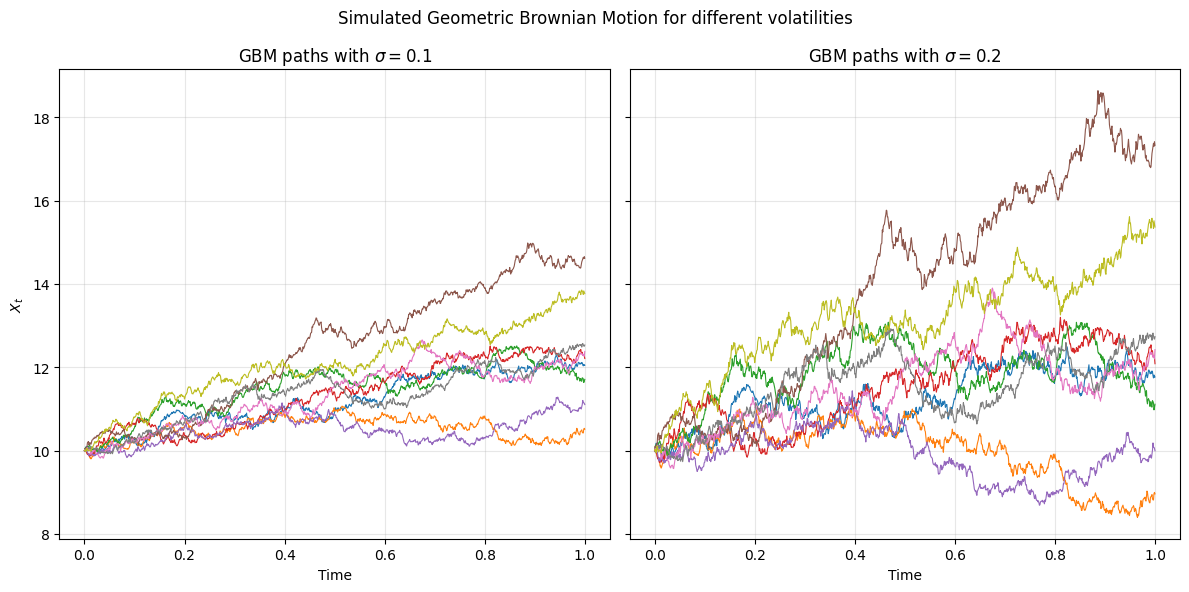

In [35]:
#Parameters
X0 = 10
mu = 0.2
sigma1 = 0.1
sigma2=0.2
T = 1
Ndt = 1000
Nsims = 500

def simulate_GBM(X0, mu, sigma, T, Ndt, Nsims=10):
    # create time increment
    dt = T / Ndt
    
    # set the different times as a vector
    time = np.linspace(0, T, Ndt+1)
    
    # initialize the matrix for GBMs
    X = np.zeros((Ndt+1,Nsims))
    
    # initial value of the process
    X[0,:] = X0
    
    # recursively simulate the process ( S[idx,:] is (1 , Nsims) )
    for idx in range(Ndt):
        Z = np.random.randn(Nsims)
        # or Z = np.random.normal(0.0, 1.0, size=(1,Nsims))
        X[idx+1,:] = X[idx,:] * np.exp( (mu - (sigma**2)/2) * dt
                                      + sigma * np.sqrt(dt) * Z)
    
    return time, X

np.random.seed(42)
t1, X1 = simulate_GBM(X0, mu, sigma1, T, Ndt, Nsims)

np.random.seed(42)
t2, X2 = simulate_GBM(X0, mu, sigma2, T, Ndt, Nsims)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].plot(t1, X1[:,1:10], linewidth=0.8)
axes[0].set_title(r"GBM paths with $\sigma = 0.1$")
axes[0].set_xlabel("Time")
axes[0].set_ylabel(r"$X_t$")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t2, X2[:,1:10], linewidth=0.8)
axes[1].set_title(r"GBM paths with $\sigma = 0.2$")
axes[1].set_xlabel("Time")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Simulated Geometric Brownian Motion for different volatilities")
plt.tight_layout()
plt.show()
